In [248]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime, hl1, hl1prime
from matplotlib.pyplot import imshow
import matplotlib.cm as cm
from matplotlib.pyplot import contourf

### We check that if we use the multilayer formalism for a finite thickness (with thickness d) thin film, our closed-form solutions for an infinitely thin coating hold in the limit $d\rightarrow 0$

In [6]:
# Finding the closed form conductivities:
M = 10000
epsilon = 2.1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

In [9]:
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigmas_real = sigmas[0, :]
sigmas_imaginary = sigmas[1, :]

In [2]:
def recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR):

    x = sqrt(epsilon2) * kR
    y = sqrt(epsilon1) * kR
    
    mat1_11 = hl1(l, y)
    mat1_12 = hl2(l, y)
    
    yhl1_prime = hl1(l, y) + y * hl1prime(l, y)
    yhl2_prime = hl2(l, y) + y * hl2prime(l, y)
    
    mat1_21 = epsilon2 * yhl1_prime
    mat1_22 = epsilon2 * yhl2_prime
    
    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    
    mat2_11 = epsilon1 * xhl2_prime
    mat2_12 = -hl2(l, x)
    
    mat2_21 = -epsilon1 * xhl1_prime
    mat2_22 = hl1(l, x)
    
    
    mat1 = np.array([[mat1_11, mat1_12], [mat1_21, mat1_22]])
    mat2 = np.array([[mat2_11, mat2_12], [mat2_21, mat2_22]])
    
    next_coefficients = np.einsum("ij..., jk..., k...->i...", mat2, mat1, previous_coefficients)

    return next_coefficients

In [359]:
N, M, K = 200, 200, 100
l = 1
kR = np.linspace(0.02, 1, K).reshape((1, 1, K)).repeat(N, axis=0).repeat(M, axis=1)
kd = 0.1*kR

sigma_real = linspace(0, 1, N).reshape((N, 1, 1)).repeat(M, axis=1).repeat(K, axis=2)
sigma_imaginary = linspace(0, 3, M).reshape((1, M, 1)).repeat(N, axis=0).repeat(K, axis=2)

previous_coefficients = np.array([1, 1])

epsilon1 = 2.1*np.ones((N, M, K)) # Take a fixed dielectric constant for silica 
epsilon_thin_film = 1 + 1j*(sigma_real + 1j*sigma_imaginary)/(kd)
epsilon2 = 1*np.ones((N, M, K)) 

next_coefficients = recursive_cpa(previous_coefficients, l, epsilon1, epsilon_thin_film, kR-kd)

# The dielectric constant will be depend on the thickness: epsilon = 1+ i*sigma/(omega*epsilon_0*d)
# If we write this in terms of normalized conductivities, simga_primes, (in units of c*epsilon_0), we obtain
# epsilon = 1+ i*sigma_prime/(omega*d/c) = 1+ i*sigma_prime/(k*d)
# Therefore, the only free parameters are the unitless quantities, kR and kd. 

next_coefficients = recursive_cpa(next_coefficients, l, epsilon_thin_film, epsilon2, kR)

scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2


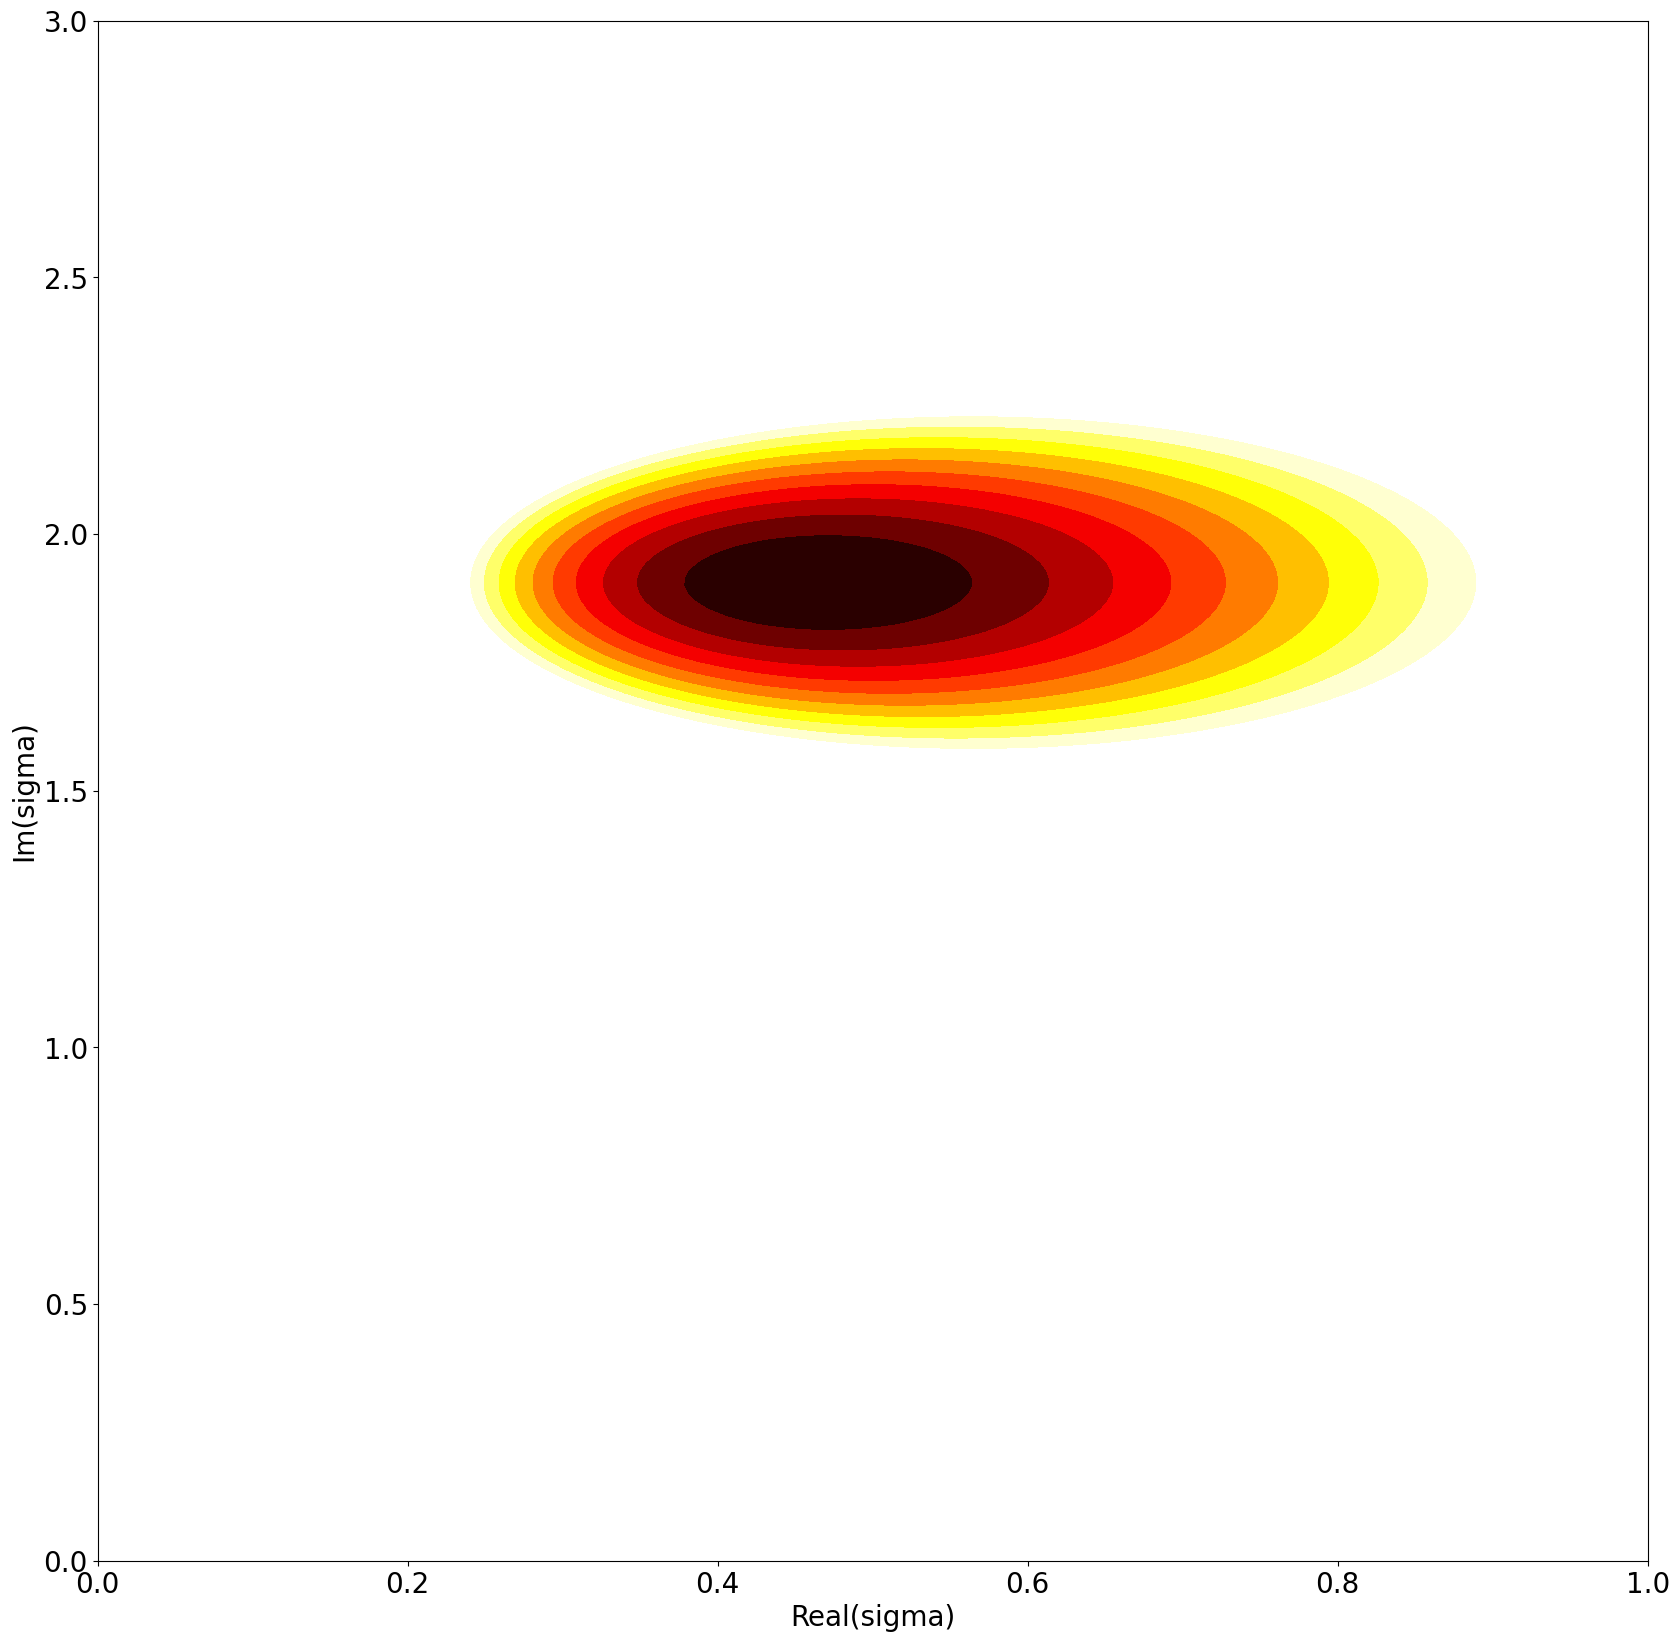

In [360]:
plt.rcParams.update({'font.size': 20})
kR_idx = 75
fig, ax = plt.subplots(figsize=(20, 20))
ax.contourf(sigma_real[:, :, 0], sigma_imaginary[:, :, 0], scattering_amplitudes[:, :, kR_idx], levels=100, cmap="hot", vmin=0, vmax=1e-1)
ax.set_xlabel("Real(sigma)");
ax.set_ylabel("Im(sigma)");

In [361]:
argmin_indices = [scattering_amplitudes[:, :, i].argmin() for i in range(0, 100)]
flattened_sigma_real = sigma_real[:, :, 0].flatten()
flattened_sigma_imaginary = sigma_imaginary[:, :, 0].flatten()

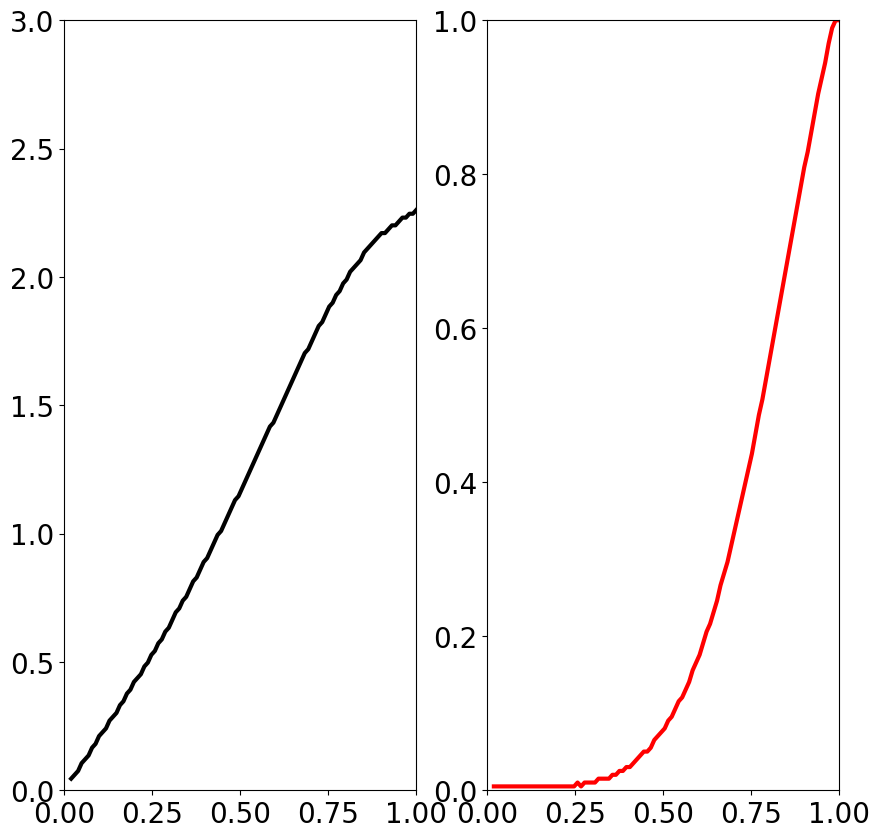

In [363]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))
ax1.plot(kR[0, 0, :], flattened_sigma_imaginary[argmin_indices], linewidth=3, color="black")
ax2.plot(kR[0, 0, :], flattened_sigma_real[argmin_indices], linewidth=3, color="red")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1);